In [ ]:
# Download Kvasir v2 (classification dataset, 2.3GB)
!wget --no-check-certificate https://datasets.simula.no/downloads/kvasir/kvasir-dataset-v2.zip


# Unzip it
!unzip -q kvasir-dataset-v2.zip -d kvasir_v2


# Check what we got
!ls kvasir_v2


--2026-07-23 08:51:50--  https://datasets.simula.no/downloads/kvasir/kvasir-dataset-v2.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 2489312085 (2.3G) [application/zip]
Saving to: ‘kvasir-dataset-v2.zip’

kvasir-dataset-v2.z 100%[===================>]   2.32G  4.23MB/s    in 5m 45s  

2026-07-23 08:57:36 (6.87 MB/s) - ‘kvasir-dataset-v2.zip’ saved [2489312085/2489312085]

kvasir-dataset-v2


In [ ]:
!ls kvasir_v2/kvasir-dataset-v2/

dyed-lifted-polyps	esophagitis   normal-pylorus  polyps
dyed-resection-margins	normal-cecum  normal-z-line   ulcerative-colitis


In [ ]:
import os, shutil, random
from sklearn.model_selection import train_test_split


SOURCE_DIR = "kvasir_v2/kvasir-dataset-v2"  # adjust to actual folder name after unzip
OUTPUT_DIR = "kvasir_v2_split"
classes = os.listdir(SOURCE_DIR)


random.seed(42)


for cls in classes:
   files = os.listdir(os.path.join(SOURCE_DIR, cls))
   train_files, temp_files = train_test_split(files, test_size=0.3, random_state=42)
   val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)


   for split_name, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
       split_cls_dir = os.path.join(OUTPUT_DIR, split_name, cls)
       os.makedirs(split_cls_dir, exist_ok=True)
       for f in split_files:
           shutil.copy(os.path.join(SOURCE_DIR, cls, f), os.path.join(split_cls_dir, f))


print("Done. Check counts per class per split.")


Done. Check counts per class per split.


In [ ]:
for split in ["train", "val", "test"]:
   print(f"\n--- {split} ---")
   for cls in os.listdir(f"{OUTPUT_DIR}/{split}"):
       n = len(os.listdir(f"{OUTPUT_DIR}/{split}/{cls}"))
       print(f"{cls}: {n}")



--- train ---
dyed-resection-margins: 700
esophagitis: 700
normal-pylorus: 700
polyps: 700
ulcerative-colitis: 700
normal-z-line: 700
dyed-lifted-polyps: 700
normal-cecum: 700

--- val ---
dyed-resection-margins: 150
esophagitis: 150
normal-pylorus: 150
polyps: 150
ulcerative-colitis: 150
normal-z-line: 150
dyed-lifted-polyps: 150
normal-cecum: 150

--- test ---
dyed-resection-margins: 150
esophagitis: 150
normal-pylorus: 150
polyps: 150
ulcerative-colitis: 150
normal-z-line: 150
dyed-lifted-polyps: 150
normal-cecum: 150


In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO


model = YOLO("yolov8n-cls.pt")  # nano — fast to train, good baseline. Can upgrade to yolov8s-cls.pt later if accuracy needs a boost


results = model.train(
   data="kvasir_v2_split",   # path to the folder containing train/ and val/
   epochs=30,
   imgsz=224,
   batch=32,
   patience=5,   # early stopping if val accuracy stalls
   project="kvasir_classifier",
   name="yolov8n_cls_run1"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kvasir_v2_split, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, fr

In [ ]:
from ultralytics import YOLO

# Load the best checkpoint from training
model = YOLO("/content/runs/classify/kvasir_classifier/yolov8n_cls_run1/weights/best.pt")

# Evaluate on the test split specifically
metrics = model.val(data="kvasir_v2_split", split="test")

print("Top-1 accuracy:", metrics.top1)
print("Top-5 accuracy:", metrics.top5)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,445,128 parameters, 0 gradients, 3.3 GFLOPs
train: /content/kvasir_v2_split/train... found 5600 images in 8 classes ✅ 
val: /content/kvasir_v2_split/val... found 1200 images in 8 classes ✅ 
test: /content/kvasir_v2_split/test... found 1200 images in 8 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2754.6±839.6 MB/s, size: 163.6 KB)
test: Scanning /content/kvasir_v2_split/test... 1200 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 1.5Kit/s 0.8s
test: New cache created: /content/kvasir_v2_split/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 75/75 4.0it/s 18.7s
                   all      0.921          1
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Top-1 accuracy: 0.9208333492279053
Top-5 accuracy: 1.0


Val results saved to: /content/runs/classify/val


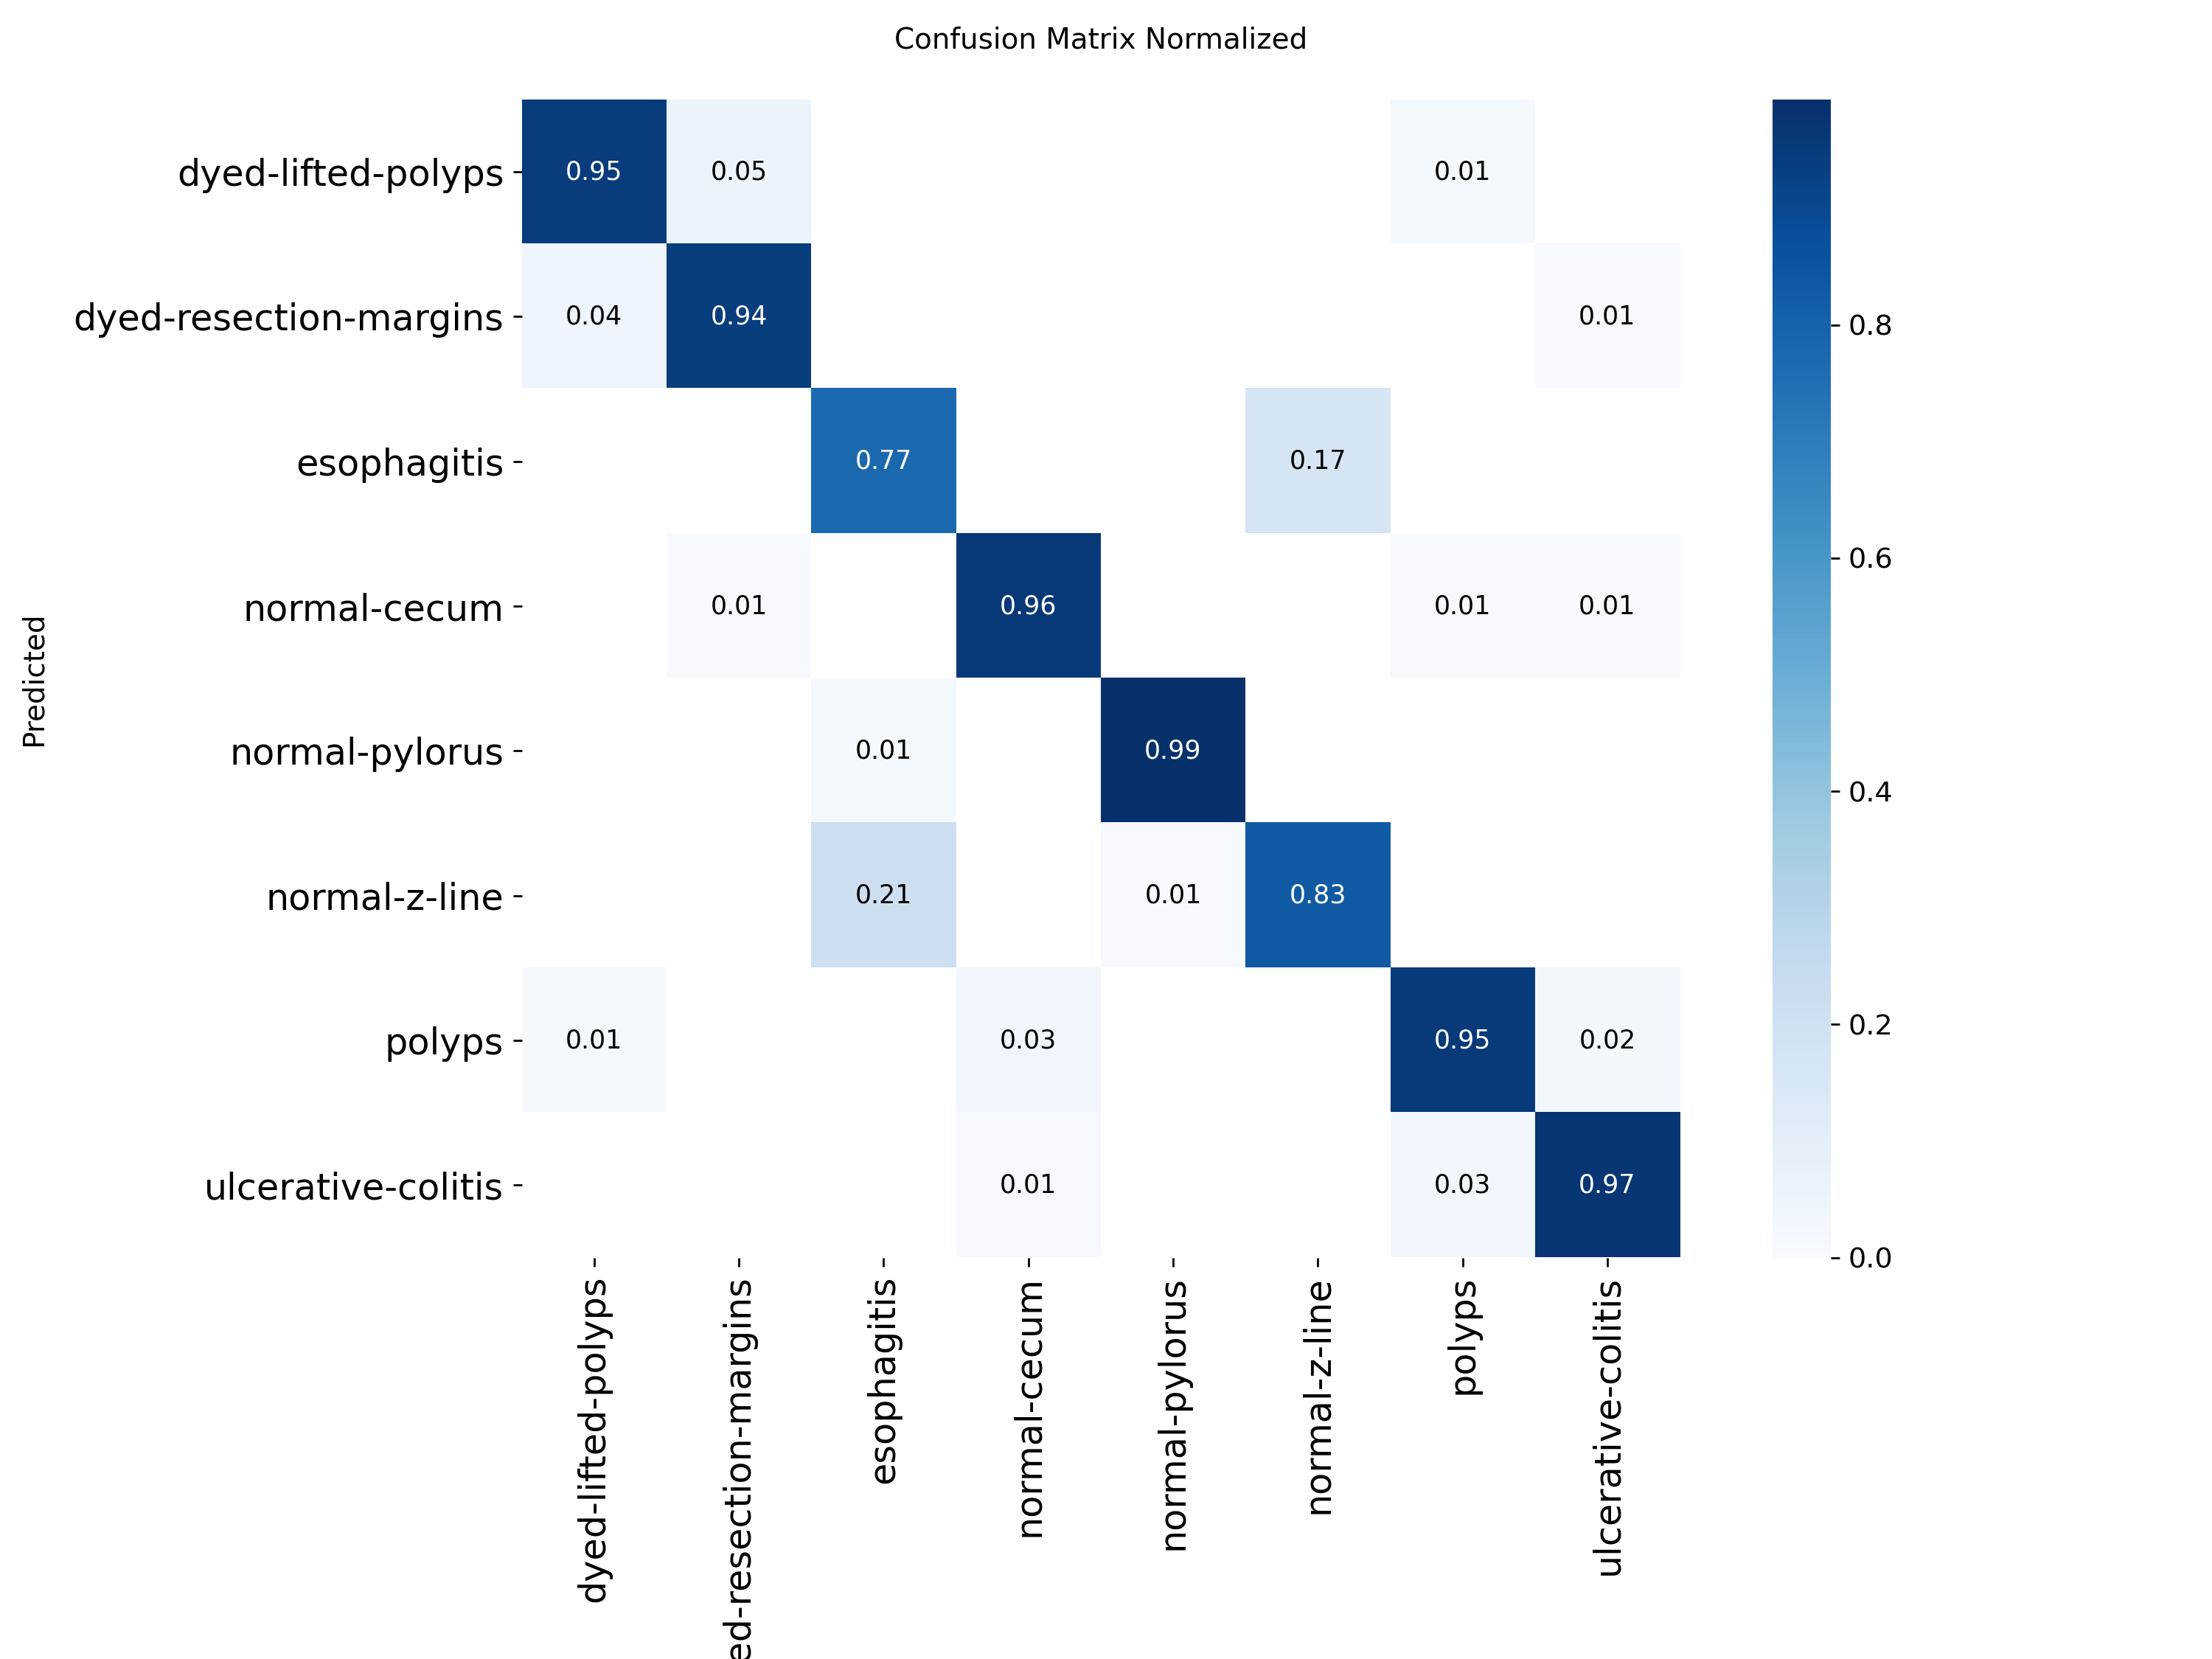

In [ ]:
import glob
from IPython.display import Image, display

val_dirs = sorted(glob.glob("/content/runs/classify/val*"))
latest_val_dir = val_dirs[-1]
print("Val results saved to:", latest_val_dir)

display(Image(f"{latest_val_dir}/confusion_matrix_normalized.png"))

In [ ]:
!wget --no-check-certificate https://datasets.simula.no/downloads/kvasir-seg.zip
!unzip -q kvasir-seg.zip -d kvasir_seg

--2026-07-23 10:21:44--  https://datasets.simula.no/downloads/kvasir-seg.zip
Resolving datasets.simula.no (datasets.simula.no)... 128.39.36.14
Connecting to datasets.simula.no (datasets.simula.no)|128.39.36.14|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 46227172 (44M) [application/zip]
Saving to: ‘kvasir-seg.zip’

kvasir-seg.zip      100%[===================>]  44.08M  9.27MB/s    in 5.9s    

2026-07-23 10:21:51 (7.44 MB/s) - ‘kvasir-seg.zip’ saved [46227172/46227172]



In [ ]:
import os

seg_root = "kvasir_seg/Kvasir-SEG"
print(os.listdir(seg_root))

images_dir = os.path.join(seg_root, "images")
masks_dir = os.path.join(seg_root, "masks")

image_files = sorted(os.listdir(images_dir))
mask_files = sorted(os.listdir(masks_dir))

print(f"Images: {len(image_files)}, Masks: {len(mask_files)}")
print("Sample filenames match:", image_files[:3], mask_files[:3])

missing = set(image_files) - set(mask_files)
print("Missing masks:", missing if missing else "None — all matched")

['images', 'masks', 'kavsir_bboxes.json']
Images: 1000, Masks: 1000
Sample filenames match: ['cju0qkwl35piu0993l0dewei2.jpg', 'cju0qoxqj9q6s0835b43399p4.jpg', 'cju0qx73cjw570799j4n5cjze.jpg'] ['cju0qkwl35piu0993l0dewei2.jpg', 'cju0qoxqj9q6s0835b43399p4.jpg', 'cju0qx73cjw570799j4n5cjze.jpg']
Missing masks: None — all matched


In [ ]:
import cv2
import numpy as np
import os

seg_root = "kvasir_seg/Kvasir-SEG"
images_dir = os.path.join(seg_root, "images")
masks_dir = os.path.join(seg_root, "masks")

labels_dir = "kvasir_seg_yolo/labels"
os.makedirs(labels_dir, exist_ok=True)

image_files = sorted(os.listdir(images_dir))
skipped = []

for fname in image_files:
    mask_path = os.path.join(masks_dir, fname)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        skipped.append(fname)
        continue

    h, w = mask.shape

    # Threshold to pure binary (masks are usually already 0/255, but just in case)
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours (each contour = one polyp blob)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label_lines = []
    for contour in contours:
        if cv2.contourArea(contour) < 50:  # skip tiny noise blobs
            continue

        # Simplify contour slightly to reduce point count (optional but keeps label files clean)
        epsilon = 0.001 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) < 3:
            continue  # need at least 3 points for a polygon

        # Normalize coordinates to 0-1 range
        points = approx.reshape(-1, 2)
        norm_points = []
        for x, y in points:
            norm_points.append(x / w)
            norm_points.append(y / h)

        # class_id 0 = polyp (single-class segmentation)
        line = "0 " + " ".join(f"{p:.6f}" for p in norm_points)
        label_lines.append(line)

    txt_name = os.path.splitext(fname)[0] + ".txt"
    with open(os.path.join(labels_dir, txt_name), "w") as f:
        f.write("\n".join(label_lines))

print(f"Converted {len(image_files) - len(skipped)} masks to YOLO polygon labels.")
print(f"Skipped/unreadable: {skipped}")

Converted 1000 masks to YOLO polygon labels.
Skipped/unreadable: []


In [ ]:
import os, shutil, random
from sklearn.model_selection import train_test_split

seg_root = "kvasir_seg/Kvasir-SEG"
images_dir = os.path.join(seg_root, "images")
labels_dir = "kvasir_seg_yolo/labels"  # from step 5.1

yolo_root = "kvasir_seg_yolo"
image_files = sorted(os.listdir(images_dir))

random.seed(42)
train_files, val_files = train_test_split(image_files, test_size=0.15, random_state=42)

print(f"Train: {len(train_files)}, Val: {len(val_files)}")

for split_name, split_files in [("train", train_files), ("val", val_files)]:
    img_out = os.path.join(yolo_root, "images", split_name)
    lbl_out = os.path.join(yolo_root, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    for fname in split_files:
        # copy image
        shutil.copy(os.path.join(images_dir, fname), os.path.join(img_out, fname))

        # copy corresponding label (same basename, .txt extension)
        label_name = os.path.splitext(fname)[0] + ".txt"
        src_label = os.path.join(labels_dir, label_name)
        dst_label = os.path.join(lbl_out, label_name)
        if os.path.exists(src_label):
            shutil.copy(src_label, dst_label)
        else:
            # create empty label file if somehow missing (shouldn't happen given your conversion)
            open(dst_label, "w").close()

print("Done organizing into train/val folders.")

Train: 850, Val: 150
Done organizing into train/val folders.


In [ ]:
yaml_content = """path: /content/kvasir_seg_yolo
train: images/train
val: images/val

names:
  0: polyp
"""

with open("kvasir_seg_yolo/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml written.")
print(yaml_content)

data.yaml written.
path: /content/kvasir_seg_yolo
train: images/train
val: images/val

names:
  0: polyp



In [ ]:
from ultralytics import YOLO

seg_model = YOLO("yolov8n-seg.pt")  # nano-seg, same reasoning as before — fast baseline first

seg_results = seg_model.train(
    data="kvasir_seg_yolo/data.yaml",
    epochs=50,
    imgsz=224,
    batch=16,
    patience=8,
    project="kvasir_segmentation",
    name="yolov8n_seg_run1"
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kvasir_seg_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg_run1-2, nbs=64, nms=False, opset=None, op

In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # skip if already mounted

import shutil, os
os.makedirs("/content/drive/MyDrive/gi_project_weights", exist_ok=True)

shutil.copy(
    "/content/runs/segment/kvasir_segmentation/yolov8n_seg_run1-2/weights/best.pt",
    "/content/drive/MyDrive/gi_project_weights/kvasir_seg_best.pt"
)
shutil.copy(
    "/content/runs/classify/kvasir_classifier/yolov8n_cls_run1/weights/best.pt",
    "/content/drive/MyDrive/gi_project_weights/kvasir_cls_best.pt"
)
print("Both models backed up to Drive.")

Mounted at /content/drive
Both models backed up to Drive.



0: 224x224 1 polyp, 72.6ms
1: 224x224 1 polyp, 72.6ms
2: 224x224 1 polyp, 72.6ms
3: 224x224 1 polyp, 72.6ms
4: 224x224 1 polyp, 72.6ms
Speed: 3.2ms preprocess, 72.6ms inference, 12.6ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/segment/predict
Predictions saved to: /content/runs/segment/predict


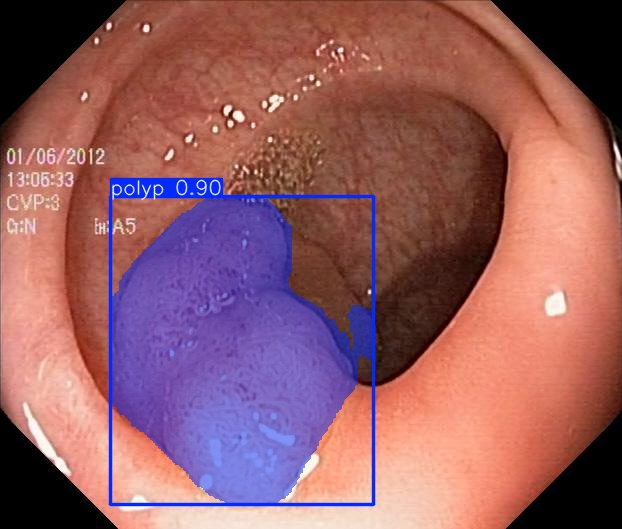

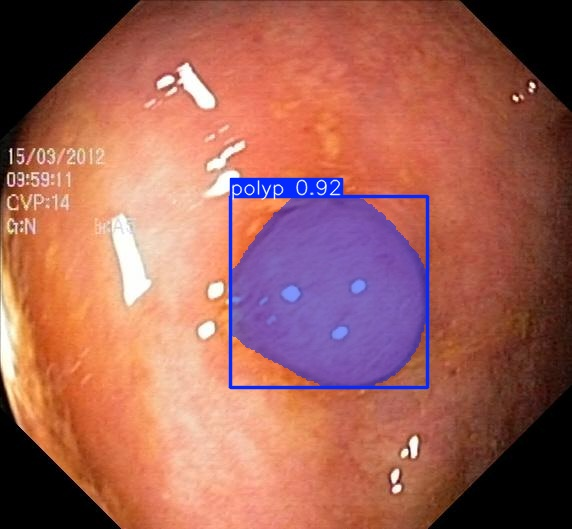

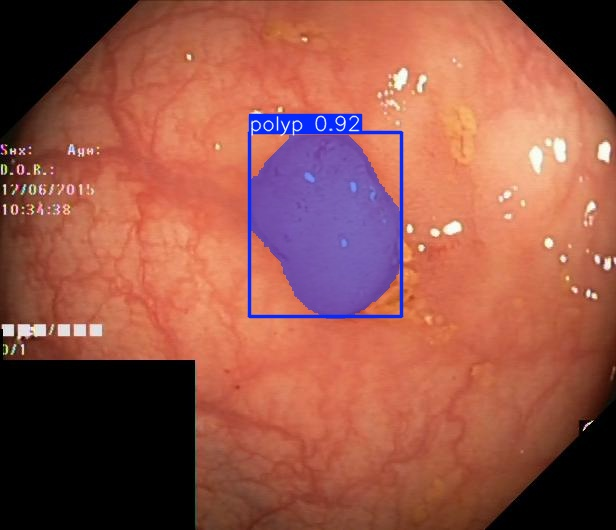

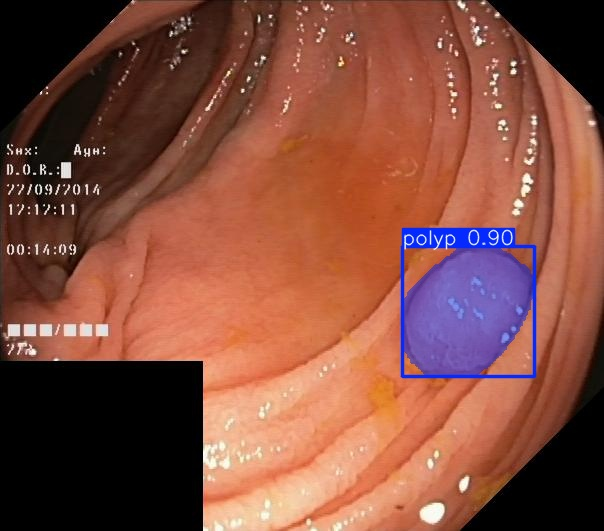

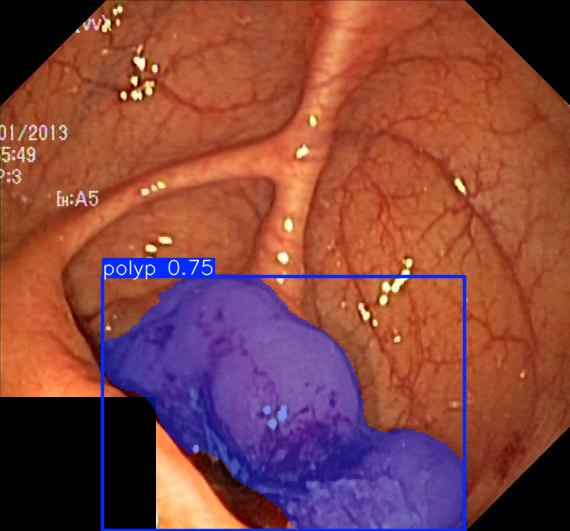

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

seg_model = YOLO("/content/runs/segment/kvasir_segmentation/yolov8n_seg_run1-2/weights/best.pt")

val_images = glob.glob("kvasir_seg_yolo/images/val/*.jpg")[:5]

results = seg_model.predict(val_images, save=True, conf=0.5)

# Find where predictions were saved
pred_dirs = sorted(glob.glob("/content/runs/segment/predict*"))
latest_pred_dir = pred_dirs[-1]
print("Predictions saved to:", latest_pred_dir)

for img_path in glob.glob(f"{latest_pred_dir}/*.jpg")[:5]:
    display(Image(img_path))

In [ ]:
from ultralytics import YOLO

cls_model = YOLO("/content/drive/MyDrive/gi_project_weights/kvasir_cls_best.pt")
seg_model = YOLO("/content/drive/MyDrive/gi_project_weights/kvasir_seg_best.pt")

print("Both models loaded.")

Both models loaded.


In [ ]:
import numpy as np
import cv2

def analyze_endoscopy_image(image_path, cls_conf_threshold=0.5, seg_conf_threshold=0.5):
    """
    Runs classification, then conditionally segmentation.
    Returns a structured dict — this is what gets passed to the LLM.
    """

    # --- Stage 1: Classification ---
    cls_results = cls_model.predict(image_path, verbose=False)
    cls_result = cls_results[0]

    top1_idx = cls_result.probs.top1
    top1_conf = float(cls_result.probs.top1conf)
    predicted_class = cls_model.names[top1_idx]

    record = {
        "predicted_class": predicted_class,
        "confidence": round(top1_conf * 100, 2),  # as percentage
        "segmentation": None
    }

    # --- Stage 2: Segmentation (only if polyp predicted) ---
    if predicted_class == "polyps" and top1_conf >= cls_conf_threshold:
        seg_results = seg_model.predict(image_path, conf=seg_conf_threshold, verbose=False)
        seg_result = seg_results[0]

        if seg_result.masks is not None and len(seg_result.masks.data) > 0:
            # Load original image to get true pixel dimensions
            img = cv2.imread(image_path)
            img_h, img_w = img.shape[:2]
            total_pixels = img_h * img_w

            # Combine all detected polyp masks (in case of multiple)
            mask_areas = []
            for mask_tensor in seg_result.masks.data:
                mask_np = mask_tensor.cpu().numpy()
                mask_resized = cv2.resize(mask_np, (img_w, img_h))
                binary_mask = (mask_resized > 0.5).astype(np.uint8)
                area_px = int(binary_mask.sum())
                mask_areas.append(area_px)

            total_polyp_area_px = sum(mask_areas)
            area_percentage = round((total_polyp_area_px / total_pixels) * 100, 2)

            # Simple qualitative size bucket — useful for the LLM prompt later
            if area_percentage < 1:
                size_desc = "small"
            elif area_percentage < 5:
                size_desc = "medium"
            else:
                size_desc = "large"

            record["segmentation"] = {
                "num_polyps_detected": len(mask_areas),
                "area_percentage_of_image": area_percentage,
                "size_description": size_desc,
                "annotated_image_path": None  # filled in step 7c
            }
        else:
            # Classifier said polyp, but segmentation model found no clear boundary
            record["segmentation"] = {
                "note": "Classifier detected a polyp, but the segmentation model could not confidently outline a boundary."
            }

    return record

In [ ]:
import os

def analyze_and_save_annotated(image_path, output_dir="annotated_outputs"):
    os.makedirs(output_dir, exist_ok=True)
    record = analyze_endoscopy_image(image_path)

    if record["segmentation"] and "area_percentage_of_image" in record["segmentation"]:
        seg_results = seg_model.predict(image_path, conf=0.5, save=False, verbose=False)
        annotated = seg_results[0].plot()  # returns numpy array with mask overlay drawn
        out_path = os.path.join(output_dir, os.path.basename(image_path))
        cv2.imwrite(out_path, annotated)
        record["segmentation"]["annotated_image_path"] = out_path

    return record

In [ ]:
import glob

test_img = glob.glob("kvasir_seg_yolo/images/val/*.jpg")[0]
result = analyze_and_save_annotated(test_img)

import json
print(json.dumps(result, indent=2))

{
  "predicted_class": "polyps",
  "confidence": 100.0,
  "segmentation": {
    "num_polyps_detected": 1,
    "area_percentage_of_image": 9.04,
    "size_description": "large",
    "annotated_image_path": "annotated_outputs/cju83rcnzkbsj0755x5anfrcg.jpg"
  }
}


In [ ]:
non_polyp_test = glob.glob("kvasir_v2_split/test/normal-cecum/*.jpg")[0]
result2 = analyze_and_save_annotated(non_polyp_test)
print(json.dumps(result2, indent=2))

{
  "predicted_class": "normal-cecum",
  "confidence": 99.67,
  "segmentation": null
}


In [61]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["SERPER_API_KEY"] = userdata.get("SERPER_API_KEY")

In [ ]:
!pip install langchain langchain-groq langchain-community google-search-results -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import langchain
import langchain_groq
import langchain_community
print("All imports successful")

All imports successful


/tmp/ipykernel_1020/1112773190.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  import langchain_community


In [ ]:
import langchain
print(langchain.__version__)

1.3.13


In [ ]:
try:
    from langchain_core.tools import Tool
except ImportError:
    try:
        from langchain.tools import Tool
    except ImportError:
        from langchain.agents import Tool

print("Tool imported successfully from:", Tool.__module__)

Tool imported successfully from: langchain_core.tools.simple


In [ ]:
from langchain.agents import create_agent

def build_system_prompt(record):
    predicted_class = record["predicted_class"]
    confidence = record["confidence"]

    seg_info = ""
    if record["segmentation"]:
        seg = record["segmentation"]
        if "area_percentage_of_image" in seg:
            seg_info = (
                f"- Segmentation: {seg['num_polyps_detected']} polyp(s) detected, "
                f"covering approximately {seg['area_percentage_of_image']}% of the image "
                f"({seg['size_description']} size)."
            )
        elif "note" in seg:
            seg_info = f"- Segmentation note: {seg['note']}"

    return f"""You are a medical information assistant helping a user understand the output of a GI endoscopy image classifier. You are NOT diagnosing the user — you are explaining a specific model output in plain language.

Model result:
- Predicted finding: {predicted_class}
- Confidence: {confidence}%
{seg_info}

Rules:
- Ground every explanation strictly in the model result above.
- Explain what this finding means in general medical terms.
- Do not hedge on or second-guess the model's output itself — treat the classification and confidence as given.
- Use the google_search tool ONLY for things like current treatment guidelines, recent research, or general disease/statistical information. Never search for anything about the user's personal situation, severity, or prognosis — answer those directly from the model result and general medical knowledge.
- When you do use search results, mention the source (e.g. "According to Mayo Clinic...").
- Always include a note that this is not a diagnosis and a doctor should confirm any finding.
- Keep answers concise and in plain, non-jargon language unless asked for more detail.
"""

def create_agent_for_record(record):
    system_prompt = build_system_prompt(record)
    agent = create_agent(
        model=llm,
        tools=tools,
        system_prompt=system_prompt
    )
    return agent

print("Agent builder ready.")

Agent builder ready.


In [ ]:
def start_chat_session(record):
    agent = create_agent_for_record(record)
    messages = [{"role": "user", "content": "Explain this result to me."}]

    result = agent.invoke({"messages": messages})
    reply = result["messages"][-1].content

    messages.append({"role": "assistant", "content": reply})
    return agent, messages, reply


def ask_followup(agent, messages, user_message):
    messages.append({"role": "user", "content": user_message})

    result = agent.invoke({"messages": messages})
    reply = result["messages"][-1].content

    messages.append({"role": "assistant", "content": reply})
    return messages, reply

In [ ]:
from langchain_groq import ChatGroq
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import Tool

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3,
    groq_api_key=os.environ["GROQ_API_KEY"]
)

search = GoogleSerperAPIWrapper()

search_tool = Tool(
    name="google_search",
    func=search.run,
    description=(
        "Use this to search Google for current medical information — things like "
        "recent treatment guidelines, general disease information, or how common a "
        "condition is. Do NOT use this for questions about the user's personal "
        "situation or severity — those should be answered from the model result "
        "already provided, not searched."
    )
)

tools = [search_tool]

print("LLM and search tool ready.")

LLM and search tool ready.


In [ ]:
agent, messages, first_reply = start_chat_session(result)  # your polyp record from earlier
print("--- Initial explanation ---")
print(first_reply)

messages, reply2 = ask_followup(agent, messages, "Is this serious?")
print("\n--- Is this serious? (should NOT trigger search) ---")
print(reply2)

messages, reply3 = ask_followup(agent, messages, "What are the latest treatment guidelines for colon polyps?")
print("\n--- Latest guidelines (SHOULD trigger search) ---")
print(reply3)

--- Initial explanation ---
The model has found something called polyps in your GI endoscopy image. Polyps are growths on the lining of your gastrointestinal tract. The model is 100% sure it saw these polyps, and it found one of them, which is quite large, covering about 9% of the image. This is not a diagnosis, and a doctor should confirm any finding. A doctor would need to examine the results and possibly do more tests to determine what this means for your health and what to do next.

--- Is this serious? (should NOT trigger search) ---
The presence of polyps can be a serious finding, as some polyps can potentially develop into cancer over time. However, not all polyps are cancerous, and many are benign (non-cancerous). The fact that the model detected a large polyp suggests that it's worth a doctor's attention. A doctor would need to evaluate the polyp and determine the best course of action, which might include removing the polyp or monitoring it for changes. This is not a diagnosi

In [65]:
%%writefile app.py
import streamlit as st
from ultralytics import YOLO
import cv2
import numpy as np
import os
import tempfile

from langchain_groq import ChatGroq
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import Tool
from langchain.agents import create_agent
from groq import BadRequestError

# ---------- Config ----------
st.set_page_config(page_title="GI Endoscopy Assistant", layout="wide")

CLS_MODEL_PATH = "/content/drive/MyDrive/gi_project_weights/kvasir_cls_best.pt"
SEG_MODEL_PATH = "/content/drive/MyDrive/gi_project_weights/kvasir_seg_best.pt"

# ---------- Load models once (cached across reruns) ----------
@st.cache_resource
def load_models():
    cls_model = YOLO(CLS_MODEL_PATH)
    seg_model = YOLO(SEG_MODEL_PATH)
    return cls_model, seg_model

@st.cache_resource
def load_agent_components():
    try:
        llm = ChatGroq(
            model="llama3-groq-70b-8192-tool-use-preview",
            temperature=0.3,
            groq_api_key=os.environ["GROQ_API_KEY"]
        )
        llm.invoke("test")
    except Exception:
        llm = ChatGroq(
            model="llama-3.3-70b-versatile",
            temperature=0.3,
            groq_api_key=os.environ["GROQ_API_KEY"]
        )

    search = GoogleSerperAPIWrapper()
    search_tool = Tool(
        name="google_search",
        func=search.run,
        description=(
            "Use this to search Google for current medical information — things like "
            "recent treatment guidelines, general disease information, or how common a "
            "condition is. Do NOT use this for questions about the user's personal "
            "situation or severity — those should be answered from the model result "
            "already provided, not searched."
        )
    )
    return llm, [search_tool]

cls_model, seg_model = load_models()
llm, tools = load_agent_components()


# ---------- Helper: safely extract text from either a message object or a dict ----------
def extract_text(msg):
    if isinstance(msg, dict):
        return msg.get("content", "")
    return getattr(msg, "content", str(msg))


# ---------- Safe agent invocation (handles Groq tool_use_failed bug) ----------
def safe_agent_invoke(agent, messages, retries=1):
    try:
        return agent.invoke({"messages": messages})
    except BadRequestError:
        if retries > 0:
            return safe_agent_invoke(agent, messages, retries=retries - 1)
        else:
            return {
                "messages": messages + [{
                    "role": "assistant",
                    "content": (
                        "I had trouble completing a search just now, so here's what I can say "
                        "from the model result alone: please discuss this finding with a doctor "
                        "for next steps and any follow-up questions about treatment."
                    )
                }]
            }


# ---------- Pipeline functions ----------
def analyze_endoscopy_image(image_path, cls_conf_threshold=0.5, seg_conf_threshold=0.5):
    cls_results = cls_model.predict(image_path, verbose=False)
    cls_result = cls_results[0]

    top1_idx = cls_result.probs.top1
    top1_conf = float(cls_result.probs.top1conf)
    predicted_class = cls_model.names[top1_idx]

    record = {
        "predicted_class": predicted_class,
        "confidence": round(top1_conf * 100, 2),
        "segmentation": None
    }

    annotated_image = None

    if predicted_class == "polyps" and top1_conf >= cls_conf_threshold:
        seg_results = seg_model.predict(image_path, conf=seg_conf_threshold, verbose=False)
        seg_result = seg_results[0]

        if seg_result.masks is not None and len(seg_result.masks.data) > 0:
            img = cv2.imread(image_path)
            img_h, img_w = img.shape[:2]
            total_pixels = img_h * img_w

            mask_areas = []
            for mask_tensor in seg_result.masks.data:
                mask_np = mask_tensor.cpu().numpy()
                mask_resized = cv2.resize(mask_np, (img_w, img_h))
                binary_mask = (mask_resized > 0.5).astype(np.uint8)
                mask_areas.append(int(binary_mask.sum()))

            total_polyp_area_px = sum(mask_areas)
            area_percentage = round((total_polyp_area_px / total_pixels) * 100, 2)

            if area_percentage < 1:
                size_desc = "small"
            elif area_percentage < 5:
                size_desc = "medium"
            else:
                size_desc = "large"

            record["segmentation"] = {
                "num_polyps_detected": len(mask_areas),
                "area_percentage_of_image": area_percentage,
                "size_description": size_desc
            }

            annotated_bgr = seg_result.plot()
            annotated_image = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
        else:
            record["segmentation"] = {
                "note": "Classifier detected a polyp, but the segmentation model could not confidently outline a boundary."
            }

    return record, annotated_image


def build_system_prompt(record):
    predicted_class = record["predicted_class"]
    confidence = record["confidence"]

    seg_info = ""
    if record["segmentation"]:
        seg = record["segmentation"]
        if "area_percentage_of_image" in seg:
            seg_info = (
                f"- Segmentation: {seg['num_polyps_detected']} polyp(s) detected, "
                f"covering approximately {seg['area_percentage_of_image']}% of the image "
                f"({seg['size_description']} size)."
            )
        elif "note" in seg:
            seg_info = f"- Segmentation note: {seg['note']}"

    return f"""You are a medical information assistant helping a user understand the output of a GI endoscopy image classifier. You are NOT diagnosing the user — you are explaining a specific model output in plain language.

Model result:
- Predicted finding: {predicted_class}
- Confidence: {confidence}%
{seg_info}

Rules:
- Ground every explanation strictly in the model result above.
- Explain what this finding means in general medical terms.
- Do not hedge on or second-guess the model's output itself — treat the classification and confidence as given.
- Use the google_search tool ONLY for things like current treatment guidelines, recent research, or general disease/statistical information. Never search for the user's personal situation, severity, or prognosis — answer those directly.
- When you use search results, mention the source (e.g. "According to Mayo Clinic...").
- Always include a note that this is not a diagnosis and a doctor should confirm any finding.
- Keep answers concise and in plain, non-jargon language unless asked for more detail.
"""


def get_agent_for_record(record):
    system_prompt = build_system_prompt(record)
    return create_agent(model=llm, tools=tools, system_prompt=system_prompt)


# ---------- Streamlit UI ----------
st.title("🩺 GI Endoscopy Image Assistant")
st.caption("Upload an endoscopy image to get a classification, polyp segmentation (if applicable), and a chat assistant to explain the result.")

uploaded_file = st.file_uploader("Upload an endoscopy image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".jpg") as tmp:
        tmp.write(uploaded_file.read())
        tmp_path = tmp.name

    if "last_uploaded_name" not in st.session_state or st.session_state.last_uploaded_name != uploaded_file.name:
        with st.spinner("Analyzing image..."):
            record, annotated_image = analyze_endoscopy_image(tmp_path)

        st.session_state.record = record
        st.session_state.annotated_image = annotated_image
        st.session_state.last_uploaded_name = uploaded_file.name
        st.session_state.agent = get_agent_for_record(record)
        st.session_state.chat_messages = [{"role": "user", "content": "Explain this result to me."}]

        with st.spinner("Generating explanation..."):
            result = safe_agent_invoke(st.session_state.agent, st.session_state.chat_messages)
        first_reply = extract_text(result["messages"][-1])
        st.session_state.chat_messages.append({"role": "assistant", "content": first_reply})

    record = st.session_state.record
    annotated_image = st.session_state.annotated_image

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Original Image")
        st.image(tmp_path, use_container_width=True)

    with col2:
        st.subheader("Result")
        st.metric("Predicted Finding", record["predicted_class"])
        st.progress(record["confidence"] / 100)
        st.write(f"Confidence: **{record['confidence']}%**")

        if record["segmentation"] and "area_percentage_of_image" in record["segmentation"]:
            seg = record["segmentation"]
            st.write(f"Polyps detected: **{seg['num_polyps_detected']}**")
            st.write(f"Area of image: **{seg['area_percentage_of_image']}%** ({seg['size_description']})")
            if annotated_image is not None:
                st.image(annotated_image, caption="Segmented polyp region", use_container_width=True)
        elif record["segmentation"] and "note" in record["segmentation"]:
            st.info(record["segmentation"]["note"])

    st.divider()

    st.subheader("💬 Ask about this result")

    for msg in st.session_state.chat_messages:
        if msg["role"] == "user" and msg["content"] == "Explain this result to me.":
            continue
        with st.chat_message(msg["role"]):
            st.write(msg["content"])

    user_input = st.chat_input("Ask a follow-up question...")

    if user_input:
        st.session_state.chat_messages.append({"role": "user", "content": user_input})
        with st.chat_message("user"):
            st.write(user_input)

        with st.spinner("Thinking..."):
            result = safe_agent_invoke(st.session_state.agent, st.session_state.chat_messages)
            reply = extract_text(result["messages"][-1])

        st.session_state.chat_messages.append({"role": "assistant", "content": reply})
        with st.chat_message("assistant"):
            st.write(reply)

else:
    st.info("Upload an image to get started.")

Overwriting app.py


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠇

In [53]:
!pip install pyngrok -q

In [59]:
from pyngrok import ngrok
from google.colab import userdata

ngrok.set_auth_token(userdata.get("NGROK_AUTHTOKEN"))

In [66]:
import subprocess, time

!pkill -f streamlit
time.sleep(2)

process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"],
    stdout=open("streamlit_log.txt", "w"),
    stderr=subprocess.STDOUT
)
time.sleep(10)
!tail -20 streamlit_log.txt



2026-07-23 12:29:38.474 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.26.1:8501



In [67]:
# Close any previous ngrok tunnels first
ngrok.kill()

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

Your app is live at: NgrokTunnel: "https://july-rectangle-drowsily.ngrok-free.dev" -> "http://localhost:8501"
